# Titanicを原理から学ぶ実験ノート

このNotebookでは、観測する前の予想、可視化、モデルの間違い、次の問いを一つの流れとして記録します。

### このNotebookで優先するもの

1. **原理原則** — 目的変数、特徴量、欠損、分母、検証データ、リークを自分の言葉で説明する
2. **可視化** — 数字を飾るのではなく、比較・分布・不確実性を見る
3. **間違いの保存** — 外れた予想や誤分類を消さず、次の問いへ変える
4. **一回一変更** — 比較するときは、固定した条件と変えた条件を明記する
5. **所有権** — 最後の解釈と次に試す仮説は、実行者自身が書く

**対象:** 機械学習を学び始めた自分と、学習過程を追いたい第三者  
**入力:** Kaggle Titanic `train.csv`, `test.csv`  
**出力:** 検証記録、誤判定表、提出形式CSV

## 1. 学習の出発点

このNotebookを実行する前に、下の空欄を自分の言葉で埋めます。正解を書く欄ではありません。

| 問い | 実行前の自分の記録 |
|---|---|
| 生存に最も関係しそうな変数は何か。なぜか。 | **［自分で記入］** |
| 欠損値を削除すると、誰が分析から消えそうか。 | **［自分で記入］** |
| 正解率だけでは見落とすものは何か。 | **［自分で記入］** |
| 自分の予想が外れたと判断する条件は何か。 | **［自分で記入］** |

グラフを見る前に書くことが重要です。外れても消さず、そのまま残します。

## 2. 実行準備

- 乱数シードを固定します。
- グラフは色だけに依存せず、件数・比率・ラベルを併記します。
- テストデータの正解は見えないため、モデル評価には使いません。
- Kaggle公式データと小さなスモークデータを区別します。

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 42
BLUE = "#2F6690"
GOLD = "#D4A72C"
ORANGE = "#D97706"
INK = "#263238"
LIGHT_GREY = "#D9E1E5"

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
japanese_font_candidates = ["Yu Gothic", "Meiryo", "Noto Sans CJK JP", "IPAexGothic"]
japanese_font = next(
    (font for font in japanese_font_candidates if font in available_fonts),
    "DejaVu Sans",
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "font.family": japanese_font,
    "axes.unicode_minus": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
})
warnings.filterwarnings("ignore", category=FutureWarning)

print("乱数シード:", RANDOM_SEED)

乱数シード: 42


### 2.1 データの場所を解決する

Kaggleでは `/kaggle/input`、ローカルでは `data/` を探します。
「ファイルが読めた」ことと「想定した公式データである」ことは別なので、形状も確認します。

In [2]:
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_DATA_DIR = Path("data")

kaggle_candidates = []
if KAGGLE_INPUT_ROOT.exists():
    kaggle_candidates = sorted({
        path.parent
        for path in KAGGLE_INPUT_ROOT.rglob("train.csv")
        if (path.parent / "test.csv").exists()
    })

if len(kaggle_candidates) == 1:
    DATA_DIR = kaggle_candidates[0]
    OUTPUT_DIR = Path("/kaggle/working")
elif len(kaggle_candidates) > 1:
    raise RuntimeError(
        "Multiple train.csv/test.csv pairs found. Attach only the Titanic competition data: "
        f"{kaggle_candidates}"
    )
elif (LOCAL_DATA_DIR / "train.csv").exists():
    DATA_DIR = LOCAL_DATA_DIR
    OUTPUT_DIR = Path("submissions")
else:
    raise FileNotFoundError(
        "train.csv and test.csv were not found. "
        "Attach the Titanic competition data or place both files under data/."
    )

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

is_official_shape = train.shape == (891, 12) and test.shape == (418, 11)
data_mode = "公式コンペデータ" if is_official_shape else "スモークデータ"

display(Markdown(
    f"**入力先:** `{DATA_DIR}`  \\n"
    f"**データ:** {data_mode}  \\n"
    f"**学習用:** {train.shape[0]}行 × {train.shape[1]}列  \\n"
    f"**提出用:** {test.shape[0]}行 × {test.shape[1]}列"
))

**入力先:** `data`  \n**データ:** 公式コンペデータ  \n**学習用:** 891行 × 12列  \n**提出用:** 418行 × 11列

### 2.2 入力の境界

公式データは `train: 891×12`, `test: 418×11` です。形状が違う場合はスモーク実行として扱います。

In [3]:
expected_train_columns = {
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
}
expected_test_columns = expected_train_columns - {"Survived"}

checks = {
    "学習用データの列が想定どおり": set(train.columns) == expected_train_columns,
    "提出用データの列が想定どおり": set(test.columns) == expected_test_columns,
    "学習用PassengerIdに重複がない": train["PassengerId"].is_unique,
    "提出用PassengerIdに重複がない": test["PassengerId"].is_unique,
    "目的変数が0または1": set(train["Survived"].dropna().unique()).issubset({0, 1}),
    "提出用データに目的変数がない": "Survived" not in test.columns,
}
check_table = pd.DataFrame({
    "確認項目": checks.keys(),
    "合格": checks.values(),
})
display(check_table)
assert check_table["合格"].all(), "入力データの確認に失敗しました。上の表を確認してください。"

,確認項目,合格
0,学習用データの列が想定どおり,True
1,提出用データの列が想定どおり,True
2,学習用PassengerIdに重複がない,True
3,提出用PassengerIdに重複がない,True
4,目的変数が0または1,True
5,提出用データに目的変数がない,True


## 3. データを観察する

### 3.1 列名ではなく「何を測っているか」を考える

| 列 | 記録されているもの | 観察するときの問い |
|---|---|---|
| `Pclass` | チケット等級 | 等級によって生存率は違うか |
| `Sex` | 性別カテゴリ | カテゴリごとの人数と生存率はどう違うか |
| `Age` | 年齢 | 年齢分布は生存・非生存でどう違うか |
| `Fare` | 運賃 | 一部の高額運賃が平均を押し上げていないか |
| `SibSp`, `Parch` | 同乗家族数の一部 | 一人か家族同伴かで違いがあるか |

列名だけで判断せず、実際の分布と欠損を見てから使い方を決めます。

### 3.2 まず目的変数の分母を見る

生存率だけでなく、各クラスの人数を表示します。「全員を多数派に分類するだけ」の基準もここから決まります。

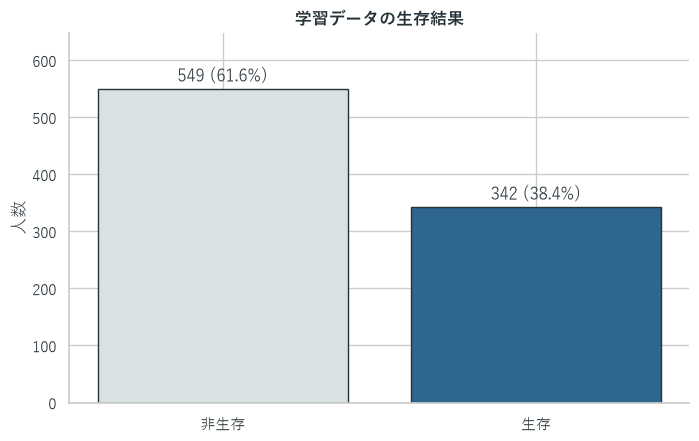

,結果,人数,割合
0,非生存,549,0.616162
1,生存,342,0.383838


In [4]:
outcome = (
    train["Survived"]
    .value_counts()
    .sort_index()
    .rename_axis("Survived")
    .reset_index(name="count")
)
outcome["label"] = outcome["Survived"].map({0: "非生存", 1: "生存"})
outcome["rate"] = outcome["count"] / outcome["count"].sum()

fig, ax = plt.subplots()
bars = ax.bar(outcome["label"], outcome["count"], color=[LIGHT_GREY, BLUE], edgecolor=INK)
ax.set_title("学習データの生存結果")
ax.set_xlabel("")
ax.set_ylabel("人数")
ax.set_ylim(0, outcome["count"].max() * 1.18)
for bar, row in zip(bars, outcome.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + outcome["count"].max() * 0.025,
        f"{row.count} ({row.rate:.1%})",
        ha="center",
    )
sns.despine(ax=ax)
plt.show()

display(
    outcome[["label", "count", "rate"]]
    .rename(columns={"label": "結果", "count": "人数", "rate": "割合"})
)

### 3.3 欠損は「面倒な空欄」ではなく観測過程の情報

欠損率と欠損件数を同時に見ます。欠損が多い列を機械的に捨てる前に、
「なぜ記録されなかったのか」「削除すると誰が消えるのか」を問います。

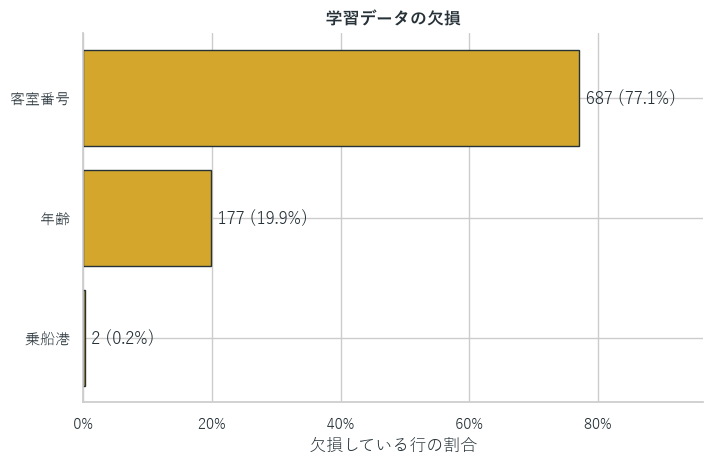

,列,表示名,欠損数,欠損率
2,Cabin,客室番号,687,0.771044
1,Age,年齢,177,0.198653
0,Embarked,乗船港,2,0.002245


In [5]:
missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_rate": train.isna().mean(),
})
missing = (
    missing[missing["missing_count"] > 0]
    .sort_values("missing_rate", ascending=True)
    .reset_index(names="feature")
)
missing["表示名"] = missing["feature"].map({
    "Cabin": "客室番号",
    "Age": "年齢",
    "Embarked": "乗船港",
})

fig, ax = plt.subplots()
bars = ax.barh(missing["表示名"], missing["missing_rate"], color=GOLD, edgecolor=INK)
ax.set_title("学習データの欠損")
ax.set_xlabel("欠損している行の割合")
ax.set_ylabel("")
ax.set_xlim(0, min(1.0, missing["missing_rate"].max() * 1.25))
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
for bar, row in zip(bars, missing.itertuples()):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{row.missing_count} ({row.missing_rate:.1%})",
        va="center",
    )
sns.despine(ax=ax)
plt.show()

display(
    missing.sort_values("missing_rate", ascending=False)
    .rename(columns={
        "feature": "列",
        "missing_count": "欠損数",
        "missing_rate": "欠損率",
    })[["列", "表示名", "欠損数", "欠損率"]]
)

**実行後の記録**

- 実行前の予想と違った欠損: **［自分で記入］**
- 欠損を削除した場合に起こりうる偏り: **［自分で記入］**
- 欠損を補うときに忘れたくないこと: **［自分で記入］**

### 3.4 グループ差は分母と不確実性を伴って読む

率だけでなく人数 `n` と95% Wilson区間を表示し、標本数による揺れも一緒に見ます。

In [6]:
def rate_with_wilson_interval(frame, group_col, target_col="Survived", z=1.96):
    summary = (
        frame.groupby(group_col, dropna=False)[target_col]
        .agg(successes="sum", n="size")
        .reset_index()
    )
    summary["rate"] = summary["successes"] / summary["n"]
    denominator = 1 + (z ** 2 / summary["n"])
    center = (summary["rate"] + z ** 2 / (2 * summary["n"])) / denominator
    half_width = (
        z
        * np.sqrt(
            summary["rate"] * (1 - summary["rate"]) / summary["n"]
            + z ** 2 / (4 * summary["n"] ** 2)
        )
        / denominator
    )
    summary["lower"] = center - half_width
    summary["upper"] = center + half_width
    return summary

def plot_group_rate(summary, group_col, title):
    plot_data = summary.sort_values("rate").reset_index(drop=True)
    if group_col == "Sex":
        plot_data["表示名"] = plot_data[group_col].map({"male": "男性", "female": "女性"})
    else:
        plot_data["表示名"] = plot_data[group_col].astype(str)
    positions = np.arange(len(plot_data))
    errors = np.vstack([
        plot_data["rate"] - plot_data["lower"],
        plot_data["upper"] - plot_data["rate"],
    ])

    fig, ax = plt.subplots()
    ax.bar(
        positions,
        plot_data["rate"],
        color=BLUE,
        edgecolor=INK,
        width=0.62,
    )
    ax.errorbar(
        positions,
        plot_data["rate"],
        yerr=errors,
        fmt="none",
        ecolor=INK,
        capsize=5,
        linewidth=1.3,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("生存率")
    ax.set_xticks(positions, plot_data["表示名"])
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    for position, row in enumerate(plot_data.itertuples()):
        ax.text(position, min(0.97, row.rate + 0.07), f"{row.rate:.1%}\nn={row.n}", ha="center")
    sns.despine(ax=ax)
    plt.show()
    return plot_data

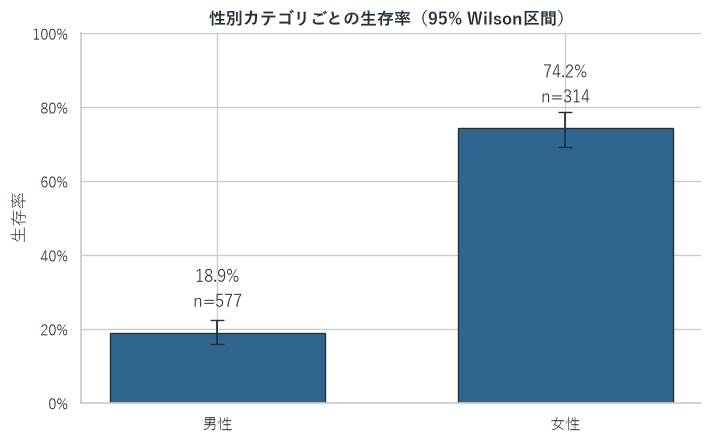

,性別カテゴリ,生存者数,人数,生存率,区間下限,区間上限,表示名
0,male,109,577,0.188908,0.159066,0.222866,男性
1,female,233,314,0.742038,0.690924,0.787301,女性


In [7]:
sex_rates = rate_with_wilson_interval(train, "Sex")
sex_rates = plot_group_rate(
    sex_rates,
    group_col="Sex",
    title="性別カテゴリごとの生存率（95% Wilson区間）",
)
display(
    sex_rates.rename(columns={
        "Sex": "性別カテゴリ",
        "successes": "生存者数",
        "n": "人数",
        "rate": "生存率",
        "lower": "区間下限",
        "upper": "区間上限",
    })
)

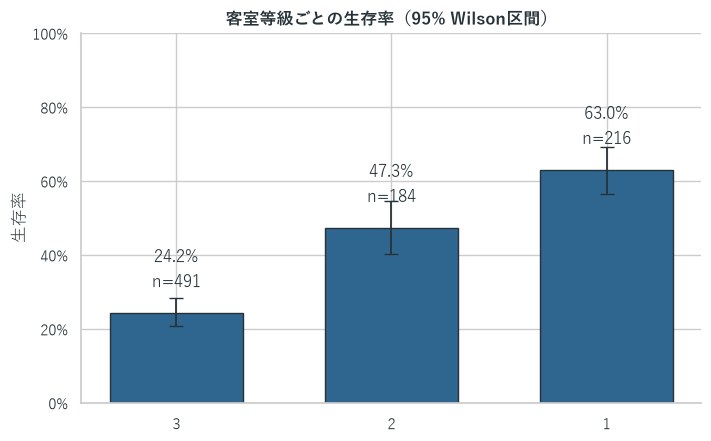

,客室等級,生存者数,人数,生存率,区間下限,区間上限,表示名
0,3,119,491,0.242363,0.206554,0.282172,3
1,2,87,184,0.472826,0.401981,0.544782,2
2,1,136,216,0.629630,0.563489,0.691240,1


In [8]:
class_rates = rate_with_wilson_interval(train, "Pclass")
class_rates = plot_group_rate(
    class_rates,
    group_col="Pclass",
    title="客室等級ごとの生存率（95% Wilson区間）",
)
display(
    class_rates.rename(columns={
        "Pclass": "客室等級",
        "successes": "生存者数",
        "n": "人数",
        "rate": "生存率",
        "lower": "区間下限",
        "upper": "区間上限",
    })
)

性別カテゴリと客室等級で生存率に差が見えました。なぜ差が生じたかは、この集計だけでは決められません。

### 3.5 平均だけでなく分布を見る

年齢は欠損を除いた観測値の分布、運賃は強い右裾を確認するため元の尺度と `log1p` 変換後を並べます。

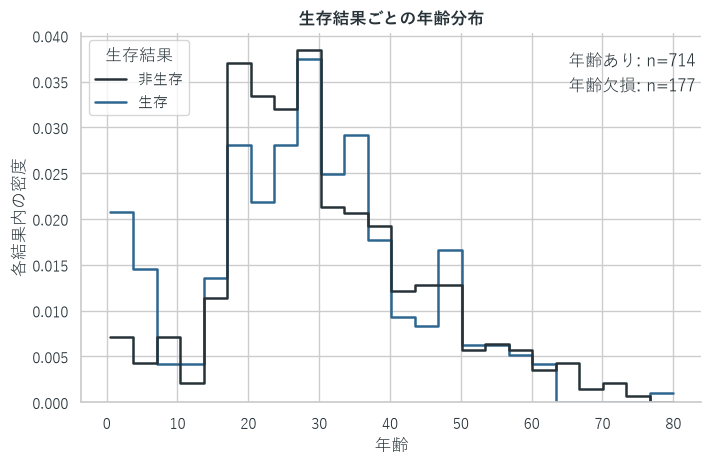

In [9]:
age_plot = train.dropna(subset=["Age"]).copy()
fig, ax = plt.subplots()
sns.histplot(
    data=age_plot,
    x="Age",
    hue="Survived",
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
    fill=False,
    palette={0: INK, 1: BLUE},
    linewidth=1.8,
    ax=ax,
)
legend = ax.get_legend()
legend.set_title("生存結果")
for text, label in zip(legend.texts, ["非生存", "生存"]):
    text.set_text(label)
ax.set_title("生存結果ごとの年齢分布")
ax.set_xlabel("年齢")
ax.set_ylabel("各結果内の密度")
ax.text(
    0.99,
    0.96,
    f"年齢あり: n={len(age_plot)}\n年齢欠損: n={train['Age'].isna().sum()}",
    transform=ax.transAxes,
    ha="right",
    va="top",
)
sns.despine(ax=ax)
plt.show()

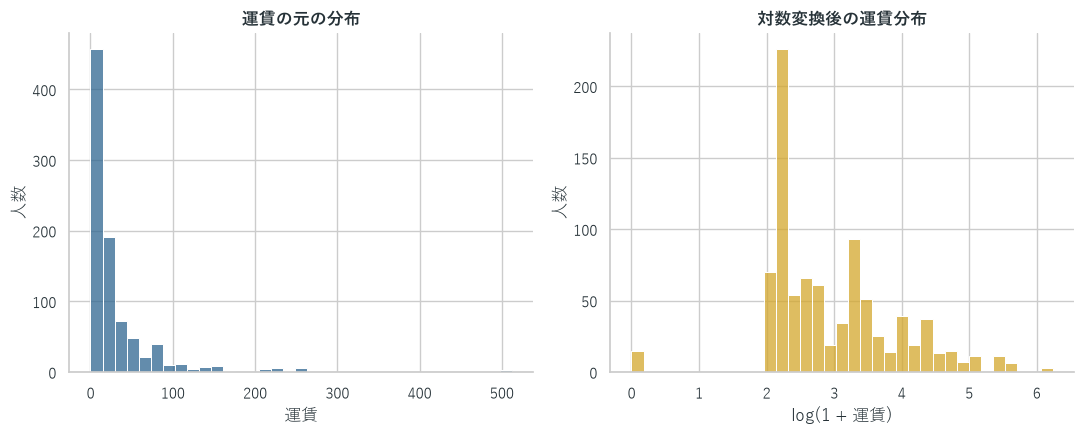

In [10]:
fare_plot = train.dropna(subset=["Fare"]).copy()
fare_plot["log1p_fare"] = np.log1p(fare_plot["Fare"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.histplot(data=fare_plot, x="Fare", bins=35, color=BLUE, edgecolor="white", ax=axes[0])
axes[0].set_title("運賃の元の分布")
axes[0].set_xlabel("運賃")
axes[0].set_ylabel("人数")

sns.histplot(data=fare_plot, x="log1p_fare", bins=35, color=GOLD, edgecolor="white", ax=axes[1])
axes[1].set_title("対数変換後の運賃分布")
axes[1].set_xlabel("log(1 + 運賃)")
axes[1].set_ylabel("人数")

for axis in axes:
    sns.despine(ax=axis)
plt.tight_layout()
plt.show()

### 3.6 観測を次の問いへ変える

| 観測 | 次に確かめたいこと | 自分の解釈 |
|---|---|---|
| 性別カテゴリで生存率が異なる | 等級や年齢をそろえても差が残るか | **［自分で記入］** |
| 等級で生存率が異なる | 船内位置に関する情報と結びつくか | **［自分で記入］** |
| `Age`, `Cabin`, `Embarked` に欠損がある | 欠損する人に偏りがあるか | **［自分で記入］** |
| 運賃分布が右に長い | 高額運賃の少数例がモデルへどう影響するか | **［自分で記入］** |

**次の比較で変えるものは一つだけ:** **［自分で記入］**

## 4. 単純なモデルを基準にする

1. `train.csv` を学習用と検証用に分ける。
2. 欠損補完・標準化・One-Hot EncodingはPipeline内で学習する。
3. 多数派予測と単純ルールを基準にする。
4. 正解率だけでなく、クラス均衡正解率、適合率、再現率、混同行列を見る。
5. 1回の分割を絶対視せず、交差検証で揺れを見る。

ここでは高度な特徴量を作らず、説明しやすい7列だけを使います。

In [11]:
target = "Survived"
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]
model_features = numeric_features + categorical_features

X = train[model_features].copy()
y = train[target].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y,
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])

display(Markdown(
    f"**学習用:** {len(X_train)}行  \\n"
    f"**検証用:** {len(X_valid)}行  \\n"
    f"**使用する列:** {', '.join(model_features)}"
))

**学習用:** 668行  \n**検証用:** 223行  \n**使用する列:** Age, SibSp, Parch, Fare, Pclass, Sex, Embarked

In [12]:
def classification_metrics(y_true, y_pred):
    return {
        "正解率": accuracy_score(y_true, y_pred),
        "クラス均衡正解率": balanced_accuracy_score(y_true, y_pred),
        "適合率（生存）": precision_score(y_true, y_pred, zero_division=0),
        "再現率（生存）": recall_score(y_true, y_pred, zero_division=0),
    }

majority_prediction = np.repeat(y_train.mode().iloc[0], len(y_valid))
simple_rule_prediction = (X_valid["Sex"] == "female").astype(int).to_numpy()

logistic_pipeline.fit(X_train, y_train)
logistic_prediction = logistic_pipeline.predict(X_valid)

holdout_metrics = pd.DataFrame({
    "多数派だけを予測": classification_metrics(y_valid, majority_prediction),
    "単純ルール：女性を生存と予測": classification_metrics(y_valid, simple_rule_prediction),
    "ロジスティック回帰": classification_metrics(y_valid, logistic_prediction),
}).T
display(holdout_metrics.round(3))

,正解率,クラス均衡正解率,適合率（生存）,再現率（生存）
多数派だけを予測,0.614,0.500,0.000,0.000
単純ルール：女性を生存と予測,0.767,0.747,0.712,0.663
ロジスティック回帰,0.776,0.757,0.725,0.674


**指標を自分の言葉へ変換する**

- **正解率:** 全体のうち正解した割合
- **クラス均衡正解率:** 生存・非生存それぞれの当てやすさを同じ重さで平均
- **適合率:** 生存と予測した人のうち、実際に生存した割合
- **再現率:** 実際に生存した人のうち、生存と拾えた割合

「どの指標を優先するか」は数学だけでは決まりません。何を見逃すことが問題なのかという目的に依存します。

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
}

majority_model = DummyClassifier(strategy="most_frequent")
cv_models = {
    "多数派だけを予測": majority_model,
    "ロジスティック回帰": logistic_pipeline,
}

cv_rows = []
for model_name, model in cv_models.items():
    result = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    cv_rows.append({
        "model": model_name,
        "accuracy_mean": result["test_accuracy"].mean(),
        "accuracy_std": result["test_accuracy"].std(ddof=1),
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": result["test_balanced_accuracy"].std(ddof=1),
    })

cv_summary = pd.DataFrame(cv_rows)
display(
    cv_summary.rename(columns={
        "model": "モデル",
        "accuracy_mean": "正解率平均",
        "accuracy_std": "正解率標準偏差",
        "balanced_accuracy_mean": "クラス均衡正解率平均",
        "balanced_accuracy_std": "クラス均衡正解率標準偏差",
    }).round(3)
)

,モデル,正解率平均,正解率標準偏差,クラス均衡正解率平均,クラス均衡正解率標準偏差
0,多数派だけを予測,0.616,0.003,0.500,0.000
1,ロジスティック回帰,0.797,0.016,0.779,0.017


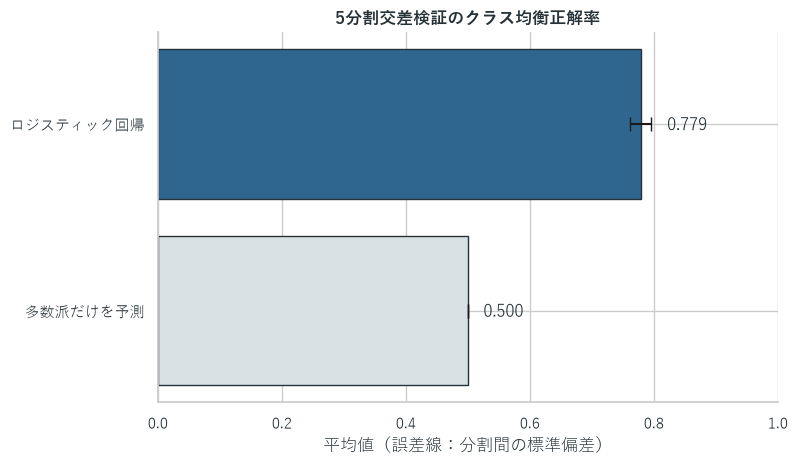

In [14]:
comparison = cv_summary.sort_values("balanced_accuracy_mean").reset_index(drop=True)
positions = np.arange(len(comparison))

fig, ax = plt.subplots()
bars = ax.barh(
    positions,
    comparison["balanced_accuracy_mean"],
    xerr=comparison["balanced_accuracy_std"],
    color=[LIGHT_GREY, BLUE],
    edgecolor=INK,
    capsize=5,
)
ax.set_title("5分割交差検証のクラス均衡正解率")
ax.set_xlabel("平均値（誤差線：分割間の標準偏差）")
ax.set_ylabel("")
ax.set_yticks(positions, comparison["model"])
ax.set_xlim(0, 1)
for bar, row in zip(bars, comparison.itertuples()):
    ax.text(
        min(0.97, row.balanced_accuracy_mean + row.balanced_accuracy_std + 0.025),
        bar.get_y() + bar.get_height() / 2,
        f"{row.balanced_accuracy_mean:.3f}",
        va="center",
    )
sns.despine(ax=ax)
plt.show()

## 5. モデルの間違いを観察する

集約スコアは「何件間違えたか」を示しますが、「どのように間違えたか」は隠します。
混同行列と誤分類行を見て、次の仮説を作ります。

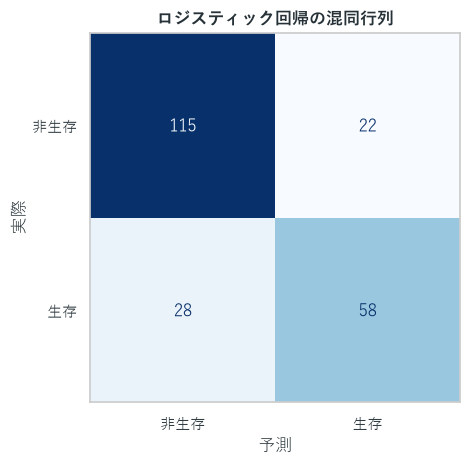

In [15]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    logistic_prediction,
    display_labels=["非生存", "生存"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("ロジスティック回帰の混同行列")
ax.set_xlabel("予測")
ax.set_ylabel("実際")
plt.grid(False)
plt.show()

In [16]:
error_rows = train.loc[X_valid.index, [
    "PassengerId", "Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Survived"
]].copy()
error_rows["Predicted"] = logistic_prediction
error_rows["誤りの種類"] = np.select(
    [
        (error_rows["Survived"] == 0) & (error_rows["Predicted"] == 1),
        (error_rows["Survived"] == 1) & (error_rows["Predicted"] == 0),
    ],
    ["偽陽性", "偽陰性"],
    default="正解",
)
mistakes = error_rows[error_rows["誤りの種類"] != "正解"].sort_values(
    ["誤りの種類", "PassengerId"]
)

error_type_summary = (
    mistakes["誤りの種類"]
    .value_counts()
    .rename_axis("誤りの種類")
    .reset_index(name="件数")
)
display(error_type_summary)
display(
    mistakes.head(12).rename(columns={
        "Pclass": "客室等級",
        "Sex": "性別カテゴリ",
        "Age": "年齢",
        "SibSp": "兄弟・配偶者数",
        "Parch": "親・子ども数",
        "Fare": "運賃",
        "Embarked": "乗船港",
        "Survived": "実際",
        "Predicted": "予測",
    })
)

,誤りの種類,件数
0,偽陰性,28
1,偽陽性,22


,PassengerId,客室等級,性別カテゴリ,年齢,兄弟・配偶者数,親・子ども数,運賃,乗船港,実際,予測,誤りの種類
17,18,2,male,NaN,0,0,13.0000,S,1,0,偽陰性
23,24,1,male,28.0,0,0,35.5000,S,1,0,偽陰性
55,56,1,male,NaN,0,0,35.5000,S,1,0,偽陰性
65,66,3,male,NaN,1,1,15.2458,C,1,0,偽陰性
146,147,3,male,27.0,0,0,7.7958,S,1,0,偽陰性
165,166,3,male,9.0,0,2,20.5250,S,1,0,偽陰性
204,205,3,male,18.0,0,0,8.0500,S,1,0,偽陰性
271,272,3,male,25.0,0,0,0.0000,S,1,0,偽陰性
279,280,3,female,35.0,1,1,20.2500,S,1,0,偽陰性
328,329,3,female,31.0,1,1,20.5250,S,1,0,偽陰性


### 誤りの記録

- 見落とした生存者（偽陰性）に共通して見える点: **［自分で記入］**
- 生存と予測した非生存者（偽陽性）に共通して見える点: **［自分で記入］**
- そのパターンは偶然かもしれない。追加で確認する分母: **［自分で記入］**
- 次の実験で固定する条件: **［自分で記入］**
- 次の実験で一つだけ変える条件: **［自分で記入］**

誤分類から作った仮説は、同じ検証データだけで確定せず、次の交差検証で確かめます。

### 5.1 提出ファイルを作る

検証が終わった同じPipelineを全訓練データへfitし、テストデータを予測します。
公式サイズでない場合は、誤提出を避けるためファイル名に `smoke` を付けます。

In [17]:
final_model = logistic_pipeline.fit(X, y)
test_prediction = final_model.predict(test[model_features])

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_prediction.astype(int),
})

assert len(submission) == len(test), "Submission row count mismatch."
assert submission["PassengerId"].equals(test["PassengerId"]), "PassengerId order changed."
assert submission["PassengerId"].is_unique, "PassengerId contains duplicates."
assert submission.isna().sum().sum() == 0, "Submission contains missing values."
assert set(submission["Survived"].unique()).issubset({0, 1}), "Predictions must be 0 or 1."

filename = (
    "submission_first_principles.csv"
    if is_official_shape
    else "submission_first_principles_smoke.csv"
)
submission_path = OUTPUT_DIR / filename
submission.to_csv(submission_path, index=False)

display(submission.head())
display(Markdown(
    f"**保存先:** `{submission_path}`  \\n"
    f"**行数:** {len(submission)}  \\n"
    f"**予測生存率:** {submission['Survived'].mean():.1%}"
))

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


**保存先:** `submissions\submission_first_principles.csv`  \n**行数:** 418  \n**予測生存率:** 36.8%

### 5.2 実行結果の要約

下のセルは、実行された値をまとめます。

In [18]:
observed_survival_rate = train["Survived"].mean()
best_cv_row = cv_summary.sort_values("balanced_accuracy_mean", ascending=False).iloc[0]
false_negatives = int((mistakes["誤りの種類"] == "偽陰性").sum())
false_positives = int((mistakes["誤りの種類"] == "偽陽性").sum())
mode_note = (
    "公式Titanicデータで実行済みです。"
    if is_official_shape
    else "スモークデータでの実行です。公開前に公式データで再実行が必要です。"
)

display(Markdown(
    "#### 実行後の要約\n\n"
    f"- 訓練データの生存率は **{observed_survival_rate:.1%}**（n={len(train)}）。\n"
    f"- 5分割交差検証のクラス均衡正解率が最も高かった比較対象は "
    f"**{best_cv_row['model']}**（平均 {best_cv_row['balanced_accuracy_mean']:.3f}, "
    f"分割間の標準偏差 {best_cv_row['balanced_accuracy_std']:.3f}）。\n"
    f"- 1回の検証分割でロジスティック回帰は偽陰性 **{false_negatives}件**、"
    f"偽陽性 **{false_positives}件**。\n"
    f"- {mode_note}"
))

#### 実行後の要約

- 訓練データの生存率は **38.4%**（n=891）。
- 5分割交差検証のクラス均衡正解率が最も高かった比較対象は **ロジスティック回帰**（平均 0.779, 分割間の標準偏差 0.017）。
- 1回の検証分割でロジスティック回帰は偽陰性 **28件**、偽陽性 **22件**。
- 公式Titanicデータで実行済みです。

## 6. 成長を記録する

### 実行後に自分で書く

1. **最初の予想:** ［自分で記入］
2. **予想と違った観測:** ［自分で記入］
3. **自分が混同していた概念:** ［自分で記入］
4. **まだ説明できない違和感:** ［自分で記入］
5. **今回「分からない」と判断したこと:** ［自分で記入］
6. **次の一回一変更実験:** ［自分で記入］
7. **その仮説を棄却する条件:** ［自分で記入］

### 次回の最小実験テンプレート

| 項目 | 記録 |
|---|---|
| 仮説 | **［自分で記入］** |
| 固定するデータ・分割・指標・モデル | **［自分で記入］** |
| 一つだけ変えるもの | **［自分で記入］** |
| 改善とみなす条件 | **［自分で記入］** |
| 悪化・無効とみなす条件 | **［自分で記入］** |
| 結果 | **［実行後に記入］** |
| 説明できない点 | **［実行後に記入］** |

---

**このNotebookの完了条件は、高いスコアではありません。**  
自分の予想、観測、誤り、限界、次の問いを第三者へ説明できれば、一つの学習サイクルが完了です。